In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, confusion_matrix, accuracy_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, SimpleRNN, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [22]:
# df = pd.read_csv("4_rnn_stock.csv")
# - What it does: Ingests the tabular CSV data file containing historical stock price records into a Pandas DataFrame.
# - Why it is important: It is the absolute entry point of our pipeline; without loading the data, no preprocessing or model training can occur.
# - Why chosen: pd.read_csv is the standard, highly optimized, and robust utility in Python for loading CSV datasets efficiently.
df = pd.read_csv("4_rnn_stock.csv")

# data = df[['Close']].values
# - What it does: Extracts the 'Close' price column as a two-dimensional NumPy array, discarding other metrics like Open or Volume.
# - Why it is important: Univariate forecasting maps history to future value of the same metric; isolating 'Close' simplifies dimensions and prevents distraction from other features.
# - Why chosen: Double brackets ensure a 2D array output (required by MinMaxScaler), and accessing '.values' converts the data to a NumPy array for direct tensor readiness.
data = df[['Close']].values

In [23]:
# scaler = MinMaxScaler()
# - What it does: Instantiates a MinMaxScaler object to map feature values into a bounded interval (defaults to 0 to 1).
# - Why it is important: Neural networks (like RNNs/LSTMs) use activation functions (tanh, sigmoid) that are highly sensitive to input scale. Scaling avoids exploding/vanishing gradients and boosts training stability.
# - Why chosen: Min-max scaling preserves the exact distribution shape while strictly bounding the data, which is ideal since stock prices are not normally distributed.
scaler = MinMaxScaler()

# data = scaler.fit_transform(data)
# - What it does: Calculates the min/max statistics on the dataset and immediately scales the closing prices to the [0, 1] range.
# - Why it is important: Performs the actual mathematical normalization of the dataset so the RNN model can ingest and learn from the values efficiently.
# - Why chosen: fit_transform combines both statistical estimation (fit) and data mapping (transform) into a single, highly optimized O(N) step.
data = scaler.fit_transform(data)

In [24]:
# ================= CREATE SEQUENCES =================

# X, y = [], []
# - What it does: Initializes empty lists X (for sequence features) and y (for sequence target labels).
# - Why it is important: Sets up dynamic containers to accumulate our sliced chronological sequences and target values.
# - Why chosen: Standard Python lists are chosen because appending elements dynamically is efficient and easy before compiling into final arrays.
X, y = [], []

# for i in range(60, len(data)):
# - What it does: Sets up a loop to slide a window across the data starting from index 60 up to the end.
# - Why it is important: Establishes the sliding window mechanism; since a window size of 60 is required, we must start at index 60 so the first sequence has sufficient history.
# - Why chosen: A range-based loop is the standard, easy-to-read way in Python to partition sequential index boundaries.
for i in range(60, len(data)):
    # X.append(data[i-60:i])
    # - What it does: Extracts a slice of 60 consecutive days of closing prices (from i-60 to i-1) and appends it to list X.
    # - Why it is important: This forms the input feature sequence that the RNN will use to learn temporal patterns over a ~3-month window.
    # - Why chosen: Slicing NumPy arrays is an efficient O(1) memory view operation, and 60 days represents a standard quarterly trading window to capture intermediate trends.
    X.append(data[i-60:i])

    # y.append(data[i])
    # - What it does: Extracts the single closing price at index i (the next day) and appends it to list y as the target.
    # - Why it is important: It defines the target label for supervised sequence learning, representing the future price the model aims to predict.
    # - Why chosen: This sets up a standard many-to-one mapping, which is the foundational supervised learning structure for time-series forecasting.
    y.append(data[i])

# X = np.array(X)
# - What it does: Converts the gathered list of input sequences into a contiguous multi-dimensional NumPy array.
# - Why it is important: Deep learning backends like Keras and TensorFlow require structured tensor formats (NumPy arrays or TF Tensors) for parallel GPU/CPU batch processing.
# - Why chosen: np.array is the standard, native method in NumPy to build an optimized contiguous tensor from Python lists.
X = np.array(X)

# y = np.array(y)
# - What it does: Converts the target list into a structured 1D NumPy array.
# - Why it is important: Target values must be a NumPy array for parallel vector computations of the loss function during model optimization.
# - Why chosen: Standard native conversion utility in the NumPy library.
y = np.array(y)

In [25]:
# ================= TRAIN TEST SPLIT =================

# split = int(0.8 * len(X))
# - What it does: Calculates the integer boundary index representing exactly 80% of our sequential dataset.
# - Why it is important: Defines the exact threshold dividing our data into training (fitting) and testing (unseen evaluation) sets.
# - Why chosen: An 80-20 split is the standard pareto-like partition in machine learning, providing sufficient data to train while reserving enough for robust verification.
split = int(0.8 * len(X))

# X_train, X_test = X[:split], X[split:]
# - What it does: Chronologically splits sequence inputs, assigning the first 80% to X_train and the last 20% to X_test.
# - Why it is important: Stock data has a critical temporal order. Slicing chronologically avoids data leakage (look-ahead bias) where future data points would predict past values.
# - Why chosen: Chronological slicing using Python indices [:split] and [split:] is highly efficient, preserves ordering, and ensures strict out-of-time evaluation.
X_train, X_test = X[:split], X[split:]

# y_train, y_test = y[:split], y[split:]
# - What it does: Chronologically splits target values, assigning the first 80% to y_train and the remaining 20% to y_test.
# - Why it is important: Ensures that target labels correspond exactly to the split sequences in X_train and X_test for proper supervised optimization.
# - Why chosen: Aligns target subsets sequentially with their corresponding training/testing feature slices without disrupting index maps.
y_train, y_test = y[:split], y[split:]

In [26]:
# model = Sequential([ ... ])
# - What it does: Instantiates a Keras Sequential model, which represents a linear stack of layers where data flows in a single direction.
# - Why it is important: Serves as the structural framework to define, stack, compile, and run our deep neural network.
# - Why chosen: Sequential is the simplest, most readable, and cleanest container class in Keras, perfectly suited for standard feeds without complex multi-branch pathways.
model = Sequential([
    # Input(shape=(60, 1)),
    # - What it does: Explicitly declares the expected input shape of the incoming data sequences (60 timesteps with 1 feature per step).
    # - Why it is important: Enables Keras to build the model structure and weight matrices immediately while avoiding deprecation warnings about implicit input shapes.
    # - Why chosen: It is the standard, modern Keras-compliant way to define the model's input dimension as a distinct starting node in the graph.
    Input(shape=(60, 1)),

    # SimpleRNN(64, return_sequences=True),
    # - What it does: Adds a Recurrent layer with 64 units, returning the hidden states for all 60 steps (return_sequences=True).
    # - Why it is important: Establishes a recurrent memory loop to learn sequential relationships; return_sequences must be True to pass a sequential 3D tensor to the next RNN.
    # - Why chosen: SimpleRNN is the foundational recurrent block. 64 units are chosen as a balanced capacity to capture intermediate-term temporal trends without overfitting.
    SimpleRNN(64, return_sequences=True),

    # Dropout(0.2),
    # - What it does: Randomly deactivates 20% of the active nodes during each training pass.
    # - Why it is important: Regularizes the network, preventing it from excessively memorizing noisy patterns in highly volatile stock data.
    # - Why chosen: A dropout rate of 0.2 is the industry-standard starting point, offering robust regularization without severely slowing down model convergence.
    Dropout(0.2),

    # SimpleRNN(64),
    # - What it does: Stacks a second recurrent layer of 64 units, returning only the final hidden state of the last step (return_sequences=False).
    # - Why it is important: Allows the network to learn higher-level hierarchical temporal representations and reduces the sequence tensor to a 2D shape for standard dense layers.
    # - Why chosen: Stacking multiple RNN layers enables the modeling of complex temporal dependencies and extracts the final consolidated state vector.
    SimpleRNN(64),

    # Dropout(0.2),
    # - What it does: Randomly deactivates 20% of the nodes outputting from the second RNN layer.
    # - Why it is important: Implements regularization on the extracted temporal states to minimize the risk of over-fitting prior to the dense transformation.
    # - Why chosen: Sustains a consistent regularization strength across layer transitions.
    Dropout(0.2),

    # Dense(25, activation='relu'),
    # - What it does: Adds a fully connected feedforward layer with 25 nodes and a Rectified Linear Unit (ReLU) activation function.
    # - Why it is important: Performs non-linear coordinate mappings to combine and reshape temporal representations towards final prediction.
    # - Why chosen: ReLU activation is standard for dense steps due to its fast convergence and protection against the vanishing gradient problem. 25 units is a standard structural step-down.
    Dense(25, activation='relu'),

    # Dropout(0.2),
    # - What it does: Randomly deactivates 20% of the dense layer nodes during training.
    # - Why it is important: Provides one last layer of regularization to ensure the final regression prediction is not overly dependent on individual hidden units.
    # - Why chosen: Standard drop step before mapping features to the final continuous output.
    Dropout(0.2),

    # Dense(1)
    # - What it does: Adds the final fully connected output layer with 1 unit and no activation function (defaults to linear).
    # - Why it is important: Represents the final continuous single-value regression target (the predicted scaled stock price).
    # - Why chosen: A single unit with linear activation is the standard, mathematically correct format for any single-target regression output.
    Dense(1)
])

# model.compile(optimizer='adam', loss='huber')
# - What it does: Compiles the model with the Adam optimization algorithm and Huber loss function.
# - Why it is important: Configures the backpropagation parameter updates and error calculation ready for training.
# - Why chosen: 'adam' uses adaptive learning rates for efficient gradient descent, and the 'huber' loss is robust to stock price outliers, transitioning gracefully from quadratic to linear error scales.
model.compile(optimizer='adam', loss='huber')

# model.summary()
# - What it does: Generates and prints a tabular summary of the model structure, shapes, and parameters.
# - Why it is important: Serves as a vital diagnostic check to verify that all layers are properly shaped and weight configurations are as expected.
# - Why chosen: It is the native Keras diagnostic summary tool.
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_4 (SimpleRNN)        │ (None, 60, 64)         │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_5 (SimpleRNN)        │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 25)             │         1,625 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 25)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,131 (55.20 KB)

 Trainable params: 14,131 (55.20 KB)

 Non-trainable params: 0 (0.00 B)

In [27]:
# early_stop = EarlyStopping( ... )
# - What it does: Instantiates Keras EarlyStopping to track model metrics and stop training if they stop improving.
# - Why it is important: Prevents unnecessary over-training and severe overfitting by ending the fit loop when validation scores plateau.
# - Why chosen: Standard, highly effective callback to manage validation convergence automatically.
early_stop = EarlyStopping(
    # monitor='val_loss',
    # - What it does: Configures EarlyStopping to monitor the loss computed on validation data.
    # - Why it is important: Validation loss is the standard proxy of real-world generalization; watching it protects the model from overfitting to training values.
    # - Why chosen: Standard validation metric for early stopping evaluation.
    monitor='val_loss',

    # patience=10,
    # - What it does: Instructs early stopping to wait 10 epochs of no improvement before terminating training.
    # - Why it is important: Prevents premature stopping due to random fluctuations or temporary training plateaus.
    # - Why chosen: 10 epochs is a standard empirical threshold that gives the optimization room to recover from local fluctuations.
    patience=10,

    # restore_best_weights=True
    # - What it does: Rolls the model's weights back to the exact epoch that recorded the absolute minimum validation loss.
    # - Why it is important: Ensures we keep the absolute optimal parameter weights, rather than the degraded weights present at the end of the patience window.
    # - Why chosen: Essential best practice to guarantee that inference is run on the best-fit version of the model.
    restore_best_weights=True
)

# history = model.fit( ... )
# - What it does: Runs the backpropagation optimization loop on the training dataset.
# - Why it is important: The core training phase where model weights are iteratively adjusted to minimize the Huber loss function.
# - Why chosen: Keras's built-in fit() function is highly optimized and standard for model training.
history = model.fit(
    # X_train, y_train,
    # - What it does: Passes the normalized historical sequences and corresponding target closing prices.
    # - Why it is important: Serves as the feature-target training set for supervised training.
    # - Why chosen: Mandatory inputs containing the training instances and targets.
    X_train,
    y_train,

    # epochs=100,
    # - What it does: Sets the maximum training iteration limit over the entire training set to 100 loops.
    # - Why it is important: Provides sufficient runway for simple RNN weights to converge, while relying on EarlyStopping to safely terminate sooner.
    # - Why chosen: A generous ceiling of 100 allows early stopping to naturally determine the exact convergence peak.
    epochs=100,

    # batch_size=32,
    # - What it does: Processes training samples in mini-batches of 32 before computing gradients and updating weights.
    # - Why it is important: Controls the speed, memory usage, and stochastic noise (regularization) during weight updates.
    # - Why chosen: 32 is a highly efficient batch standard that provides high vectorization throughput while maintaining helpful gradient variance.
    batch_size=32,

    # validation_data=(X_test, y_test),
    # - What it does: Computes loss on validation data after each epoch.
    # - Why it is important: Provides unbiased validation scores at each training step to evaluate real-time generalization and drive early stopping.
    # - Why chosen: Standard validation configuration for evaluating epochs in Keras.
    validation_data=(X_test, y_test),

    # callbacks=[early_stop],
    # - What it does: Binds the early stopping callback logic to the execution of the training loop.
    # - Why it is important: Ensures validation performance checks occur at the end of each epoch to trigger early stop conditions.
    # - Why chosen: Standard Keras callback list integration.
    callbacks=[early_stop],

    # verbose=1
    # - What it does: Prints the progress bars and metrics to standard output at each epoch.
    # - Why it is important: Provides immediate, visible feedback of losses and step times to the developer.
    # - Why chosen: Standard, highly readable interactive print setting for Jupyter notebooks.
    verbose=1
)

Epoch 1/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 11s 161ms/step - loss: 0.0548 - val_loss: 0.0189
Epoch 2/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0152 - val_loss: 0.0268
Epoch 3/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0108 - val_loss: 0.0223
Epoch 4/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0084 - val_loss: 0.0120
Epoch 5/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0068 - val_loss: 0.0156
Epoch 6/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0061 - val_loss: 0.0080
Epoch 7/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0054 - val_loss: 0.0091
Epoch 8/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0047 - val_loss: 0.0085
Epoch 9/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0043 - val_loss: 0.0026
Epoch 10/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0046 - val_loss: 0.0027
Epoch 11/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0039 - val_loss: 0.0047
Epoch 12/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/st

In [28]:
# pred = model.predict(X_test)
# - What it does: Runs test sequences X_test through the trained network to generate predictions.
# - Why it is important: Obtains the model's actual forecasted values on unseen chronological data, enabling performance testing.
# - Why chosen: predict() is Keras's standard, fully parallelized and optimized inference function.
pred = model.predict(X_test)

# pred = scaler.inverse_transform(pred)
# - What it does: Reverts the predictions back from the normalized scale [0, 1] to their original stock price values.
# - Why it is important: Scaled values [0, 1] are not human-interpretable or directly useful for evaluating real errors in terms of actual dollar amounts.
# - Why chosen: inverse_transform uses the calculated MinMax scale boundaries to mathematically reverse the normalization exactly.
pred = scaler.inverse_transform(pred)

# real = scaler.inverse_transform(y_test)
# - What it does: Reverts the target values back from the normalized scale [0, 1] to their original stock price values.
# - Why it is important: Allows direct real-world price comparison between predictions and targets in their original USD units.
# - Why chosen: Ensures scale compatibility prior to calculating error metrics or creating visualization plots.
real = scaler.inverse_transform(y_test)

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step


In [29]:
# ================= METRICS =================

# rmse = np.sqrt(mean_squared_error(real, pred))
# - What it does: Computes the Root Mean Squared Error between original-scale targets and model forecasts.
# - Why it is important: RMSE is the standard metric to quantify regression performance; squaring prevents positive/negative cancelations and penalizes large errors, and the root returns the error to the original USD scale.
# - Why chosen: Scikit-learn's mean_squared_error combined with NumPy's sqrt is the standard, optimized method in Python's data science ecosystem.
rmse = np.sqrt(mean_squared_error(real, pred)) #  Squaring ensures that positive and negative errors don't cancel each other out, and it heavily penalizes larger errors.

# print("RMSE :", rmse)
# - What it does: Prints the computed RMSE value to the output display.
# - Why it is important: Provides immediate numerical verification of prediction error on the test dataset.
# - Why chosen: Standard built-in print utility.
print("RMSE :", rmse) # Taking the square root brings the error metric back to the original scale of the data

RMSE : 9.610320398885735


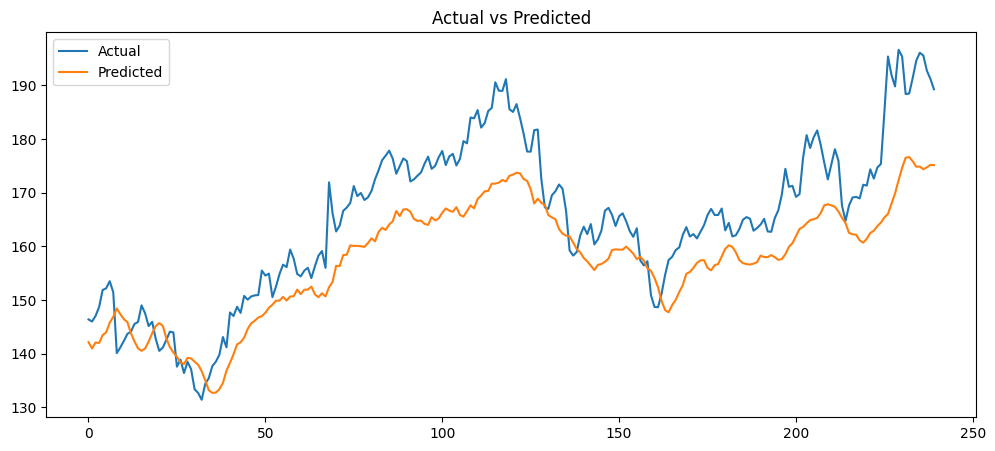

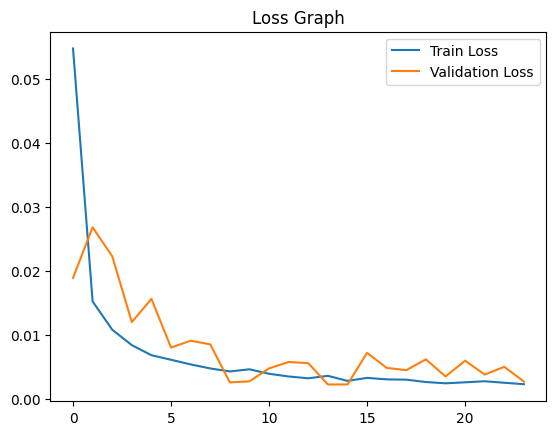

In [30]:
# ================= ACTUAL VS PREDICTED =================

# plt.figure(figsize=(12,5))
# - What it does: Creates a new plotting figure window with a width of 12 inches and a height of 5 inches.
# - Why it is important: It sets up the aspect ratio and display dimensions of the chart so that the horizontal time series is easily readable and not compressed.
# - Why chosen: A 12x5 canvas is an industry-standard wide aspect ratio that highlights sequential fluctuations and trends in daily stock predictions.
plt.figure(figsize=(12,5))

# plt.plot(real, label='Actual')
# - What it does: Plots a line chart of the actual ground-truth stock prices from the test dataset, labeling the series as 'Actual'.
# - Why it is important: Provides the historical baseline curve against which we can visually evaluate the model's accuracy.
# - Why chosen: plt.plot is the standard line-plotting function in matplotlib for continuous values.
plt.plot(real, label='Actual')

# plt.plot(pred, label='Predicted')
# - What it does: Plots a line chart of the predicted stock prices on the same canvas, labeling the series as 'Predicted'.
# - Why it is important: Superimposes the model's forecasts directly over the actual prices, allowing for a clear visual inspection of fit and lag.
# - Why chosen: Matplotlib automatically overlays multiple plot calls on the same active figure, making comparison simple.
plt.plot(pred, label='Predicted')

# plt.title("Actual vs Predicted")
# - What it does: Sets the top header title of the active figure to "Actual vs Predicted".
# - Why it is important: Clearly describes the contents and purpose of the visual chart to any reader.
# - Why chosen: Standard matplotlib title setting method.
plt.title("Actual vs Predicted")

# plt.legend()
# - What it does: Displays a legend on the plot area, showing the labels 'Actual' and 'Predicted' associated with their respective line colors.
# - Why it is important: Essential for identifying which line corresponds to real prices and which corresponds to model predictions.
# - Why chosen: Standard legend display utility.
plt.legend()

# plt.show()
# - What it does: Renders and displays the complete figure on the output screen, clearing the current figure state.
# - Why it is important: Necessary to force immediate visual output in environments like notebooks, preventing residual text logs from rendering.
# - Why chosen: Standard drawing/display method in Matplotlib.
plt.show()

# ================= LOSS GRAPH =================

# plt.plot(history.history['loss'], label='Train Loss')
# - What it does: Plots the training loss values recorded at each epoch during fitting, labeled as 'Train Loss'.
# - Why it is important: Helps diagnose model learning speed, convergence status, and whether the optimization has successfully stabilized.
# - Why chosen: Keras's history.history object naturally records loss histories at each epoch, making it perfect for rapid charting.
plt.plot(history.history['loss'], label='Train Loss')

# plt.plot(history.history['val_loss'], label='Validation Loss')
# - What it does: Plots the validation loss values recorded at each epoch, labeled as 'Validation Loss'.
# - Why it is important: Vital to detect overfitting; if validation loss starts to increase while training loss continues to decrease, the model is overfitting.
# - Why chosen: Standard validation metric visualization.
plt.plot(history.history['val_loss'], label='Validation Loss')

# plt.title("Loss Graph")
# - What it does: Sets the title of the loss chart to "Loss Graph".
# - Why it is important: Informs the viewer that this chart represents training vs validation error across epochs.
# - Why chosen: Standard matplotlib title setting method.
plt.title("Loss Graph")

# plt.legend()
# - What it does: Displays the legend for the loss curves.
# - Why it is important: Identifies the Training and Validation lines clearly.
# - Why chosen: Standard legend display utility.
plt.legend()

# plt.show()
# - What it does: Renders and displays the complete loss graph.
# - Why it is important: Visualizes convergence across epochs.
# - Why chosen: Standard draw/display method.
plt.show()

# Because the RNN is trained to predict tomorrow's price using the last 60 days, it naturally places heavy weight on the most recent day (Day 60). As a result, the prediction curve lags slightly behind sudden actual price changes.